# Matrix Surgeon

This extension turns elementary row operations into a fast visual game.

- You start with matrix **A**
- You want to reach goal matrix **G**
- Every move is one elementary row operation
- Under the hood, each move builds an elementary matrix **E** and applies: `A_new = E @ A`

## Win Condition

Reach `A == G` (within a small numeric tolerance) using the fewest moves and lowest time.


## Hypotheses for Extension Analysis

1. Correctness Hypothesis: Every row operation exactly matches left-multiplication by an elementary matrix.
2. Difficulty Hypothesis: Larger matrix size (`n`) increases average puzzle distance from start to goal.


In [6]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

ROOT = Path.cwd().resolve()
if (ROOT / 'data.py').exists():
    pass
elif (ROOT.parent / 'data.py').exists():
    ROOT = ROOT.parent
else:
    raise RuntimeError('Run from project root or extension folder.')

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from extension.matrix_surgeon import (
    MatrixSurgeonGame,
    apply_operation,
    move_to_text,
    load_scores,
    save_score,
)

plt.rcParams.update({'font.size': 11})
np.set_printoptions(precision=3, suppress=True)


## 1) Correctness Check: `A_new = E @ A`

This cell verifies the first hypothesis: each row operation is mathematically equivalent to left-multiplication by an elementary matrix, i.e., A_new = E @ A.


In [7]:
A = np.array([[2., -1., 0.],
              [1.,  3., 4.],
              [0.,  2., 5.]])

A_new, E = apply_operation(A, op_type='add', row_a=0, row_b=1, k=-2)

# Manual row operation: R2 <- R2 + (-2)*R1
manual = A.copy()
manual[1] = manual[1] + (-2) * manual[0]

print("Original A:\n", A)
print("\nElementary matrix E:\n", E)
print("\nE @ A:\n", A_new)
print("\nManual row result:\n", manual)
print("\nMatches exactly:", np.allclose(A_new, manual))


Original A:
 [[ 2. -1.  0.]
 [ 1.  3.  4.]
 [ 0.  2.  5.]]

Elementary matrix E:
 [[ 1.  0.  0.]
 [-2.  1.  0.]
 [ 0.  0.  1.]]

E @ A:
 [[ 2. -1.  0.]
 [-3.  5.  4.]
 [ 0.  2.  5.]]

Manual row result:
 [[ 2. -1.  0.]
 [-3.  5.  4.]
 [ 0.  2.  5.]]

Matches exactly: True


## 2) Difficulty Analysis: Matrix Size vs Puzzle Distance

As matrix size `n` increases (2->3->4...), puzzle distance `sum(abs(G - A))` increases on average, so practical difficulty also increases.”


Size -> avg L1 distance +/- std
2: 11.58 +/- 4.21
3: 26.95 +/- 6.57
4: 48.10 +/- 8.90


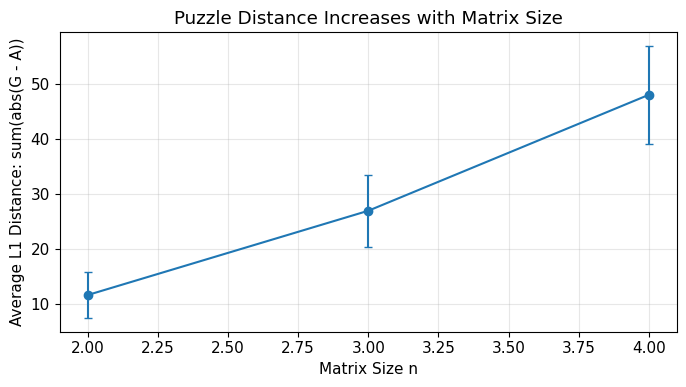

In [3]:
rng_seed = 252
sizes = [2, 3, 4]
trials_per_size = 60

avg_l1 = []
std_l1 = []

for n in sizes:
    vals = []
    game = MatrixSurgeonGame(n=n, seed=rng_seed + n)
    for _ in range(trials_per_size):
        game.new_puzzle(n=n)
        vals.append(np.sum(np.abs(game.goal_G - game.start_A)))
    vals = np.array(vals, dtype=float)
    avg_l1.append(np.mean(vals))
    std_l1.append(np.std(vals))

print('Size -> avg L1 distance +/- std')
for n, m, s in zip(sizes, avg_l1, std_l1):
    print(f'{n}: {m:.2f} +/- {s:.2f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(sizes, avg_l1, yerr=std_l1, marker='o', capsize=3)
ax.set_title('Puzzle Distance Increases with Matrix Size')
ax.set_xlabel('Matrix Size n')
ax.set_ylabel('Average L1 Distance: sum(abs(G - A))')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3) Interactive Game UI

### Controls

- `Size n`: matrix size
- `Operation`: `swap`, `scale`, or `add`
- `Row A` and `Row B`: row selectors (1-based in UI)
- `k`: scalar for `scale` and `add`
- `Apply Move`, `Undo`, `New Puzzle`, `Save Score`

### Scoring

`score = max(0, 1000 - 70*moves - 2*seconds)`


In [8]:
SCORE_PATH = ROOT / 'extension' / 'matrix_surgeon_scores.json'

state = {
    'game': MatrixSurgeonGame(n=3, seed=252),
    'last_move': None,
    'changed_mask': None,
}

# --- Widgets ---
size_dropdown = widgets.Dropdown(options=[2, 3, 4], value=3, description='Size n')
op_dropdown = widgets.Dropdown(options=['swap', 'scale', 'add'], value='add', description='Operation')
row_a = widgets.IntSlider(value=1, min=1, max=3, step=1, description='Row A')
row_b = widgets.IntSlider(value=2, min=1, max=3, step=1, description='Row B')
k_slider = widgets.FloatSlider(value=1.0, min=-3.0, max=3.0, step=0.5, description='k')
player_name = widgets.Text(value='Anonymous', description='Player')

apply_btn = widgets.Button(description='Apply Move', button_style='primary')
undo_btn = widgets.Button(description='Undo')
new_btn = widgets.Button(description='New Puzzle')
save_btn = widgets.Button(description='Save Score')

status_out = widgets.Output()
plot_out = widgets.Output()
log_out = widgets.Output()
score_out = widgets.Output()


def _update_row_limits(*_):
    n = int(size_dropdown.value)
    row_a.max = n
    row_b.max = n
    if row_a.value > n:
        row_a.value = n
    if row_b.value > n:
        row_b.value = n
    if row_a.value == row_b.value:
        row_b.value = 1 if row_a.value != 1 else min(2, n)


def _op_help_text(op):
    if op == 'swap':
        return 'swap: exchange Row A and Row B'
    if op == 'scale':
        return 'scale: Row A <- k * Row A (k must be nonzero)'
    return 'add: Row B <- Row B + k * Row A'


def _render_matrix(ax, M, title, vabs, changed_mask=None):
    ax.imshow(M, cmap='coolwarm', vmin=-vabs, vmax=vabs)
    ax.set_title(title)
    ax.set_xticks(range(M.shape[1]))
    ax.set_yticks(range(M.shape[0]))
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            color = 'black'
            if changed_mask is not None and changed_mask[i, j]:
                color = 'yellow'
            ax.text(j, i, f'{M[i, j]:.1f}', ha='center', va='center', color=color, fontsize=10)


def render():
    game = state['game']
    A = game.current_A
    G = game.goal_G
    D = G - A

    with status_out:
        clear_output(wait=True)
        print('Matrix Surgeon Status')
        print('---------------------')
        print(f'n = {game.n}')
        print(f'moves used = {game.moves_used()}')
        print(f'elapsed seconds = {game.elapsed_seconds():.1f}')
        print(f'formula: {_op_help_text(op_dropdown.value)}')

        if state['last_move'] is not None:
            print(f'last move: {move_to_text(state["last_move"])}')
            print('last E matrix:')
            print(state['last_move'].E)

        if game.solved():
            print('\nSolved!')
            print(f'score = {game.score()}')

    with plot_out:
        clear_output(wait=True)
        vabs = float(max(1.0, np.max(np.abs(A)), np.max(np.abs(G)), np.max(np.abs(D))))

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        _render_matrix(axes[0], A, 'Current A', vabs, changed_mask=state['changed_mask'])
        _render_matrix(axes[1], G, 'Goal G', vabs)
        _render_matrix(axes[2], D, 'Delta (G - A)', vabs)
        plt.tight_layout()
        plt.show()

    with log_out:
        clear_output(wait=True)
        print('Recent move log (latest 8):')
        if not game.history:
            print('  no moves yet')
        else:
            for mv in game.history[-8:]:
                print(' ', move_to_text(mv))


def on_new(_=None):
    n = int(size_dropdown.value)
    state['game'].new_puzzle(n=n)
    state['last_move'] = None
    state['changed_mask'] = None
    _update_row_limits()
    render()


def on_apply(_):
    game = state['game']
    op = op_dropdown.value
    a = int(row_a.value) - 1
    b = int(row_b.value) - 1
    k = float(k_slider.value)

    with score_out:
        clear_output(wait=True)

    try:
        before = game.current_A.copy()
        if op == 'swap':
            if a == b:
                print('Swap requires different rows.')
                return
            mv = game.apply('swap', a, row_b=b)
        elif op == 'scale':
            if np.isclose(k, 0.0):
                print('Scale requires nonzero k.')
                return
            mv = game.apply('scale', a, k=k)
        else:  # add
            if a == b:
                print('Add requires Row A != Row B.')
                return
            mv = game.apply('add', a, row_b=b, k=k)

        after = game.current_A.copy()
        state['last_move'] = mv
        state['changed_mask'] = np.abs(after - before) > 1e-9
        render()

    except Exception as e:
        with score_out:
            clear_output(wait=True)
            print(f'Operation failed: {e}')


def on_undo(_):
    mv = state['game'].undo()
    if mv is not None:
        state['last_move'] = mv
        state['changed_mask'] = np.abs(mv.after - mv.before) > 1e-9
    else:
        state['last_move'] = None
        state['changed_mask'] = None
    render()


def on_save(_):
    game = state['game']
    with score_out:
        clear_output(wait=True)
        if not game.solved():
            print('You can save a score only after solving the puzzle.')
            return

        board = save_score(
            SCORE_PATH,
            name=player_name.value,
            score=game.score(),
            moves=game.moves_used(),
            seconds=game.elapsed_seconds(),
            n=game.n,
        )

        print('Score saved. Top scores:')
        for idx, row in enumerate(board[:10], start=1):
            print(
                f"{idx:2d}. {row['name']:<12} score={row['score']:<4d} "
                f"moves={row['moves']:<3d} sec={row['seconds']:.1f} "
                f"n={row['n']}"
            )


def on_size_change(_):
    # Change puzzle immediately when size changes to keep feedback loop fast.
    on_new()


apply_btn.on_click(on_apply)
undo_btn.on_click(on_undo)
new_btn.on_click(on_new)
save_btn.on_click(on_save)

size_dropdown.observe(on_size_change, names='value')

_update_row_limits()

controls_1 = widgets.HBox([size_dropdown, op_dropdown])
controls_2 = widgets.HBox([row_a, row_b, k_slider])
controls_3 = widgets.HBox([apply_btn, undo_btn, new_btn, save_btn])


display(controls_1)
display(controls_2)
display(player_name)
display(controls_3)
display(status_out)
display(plot_out)
display(log_out)
display(score_out)

on_new()


Text(value='Anonymous', description='Player')

Output()

Output()

Output()

Output()